# House Price Predection Project

### Problem statement 
- Predict house price 

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Load data

In [39]:
df = pd.read_csv("./housing.csv")

### Exporatiory data analysis

In [40]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [41]:
# Get general information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [42]:
# Check for null values
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [44]:
# Stastical analysis
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Fill missing values

In [48]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

### Categorical data into numerical

In [49]:
# By using encoding
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True
)

In [50]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'],
      dtype='object')

### Split the data

In [54]:
# Split X and y
x = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [55]:
# Split into traning and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.7, random_state=42)

### Load the model

In [56]:
from sklearn.linear_model import LinearRegression

# Create object of linear regression
model = LinearRegression()

# Train the model
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the model

In [59]:
# Predictions
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("Training Metrics")
print("R2 Score :", r2_score(y_train, y_pred_train))
print("MAE      :", mean_absolute_error(y_train, y_pred_train))
print("MSE      :", mean_squared_error(y_train, y_pred_train))
print("RMSE     :", np.sqrt(mean_squared_error(y_train, y_pred_train)))

print("\nTesting Metrics")
print("R2 Score :", r2_score(y_test, y_pred_test))
print("MAE      :", mean_absolute_error(y_test, y_pred_test))
print("MSE      :", mean_squared_error(y_test, y_pred_test))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred_test)))

Training Metrics
R2 Score : 0.6470541628829785
MAE      : 49724.918311214285
MSE      : 4728724267.315525
RMSE     : 68765.7201468546

Testing Metrics
R2 Score : 0.6393486487434199
MAE      : 50076.16632196995
MSE      : 4732938957.24271
RMSE     : 68796.35860452725


### Visulization

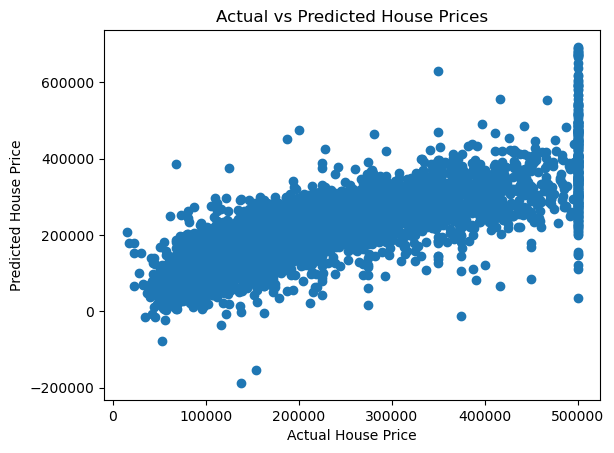

In [62]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

### Save the model

In [63]:
import pickle

with open("House_price.pkl", "wb") as file:
    pickle.dump(model, file)

In [64]:
print(x.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
